# Progetto ML: IBM HR Attrition

**Questo notebook è stato elaborato da Olga Shopieva (ADABI 2025-2026)**

## Sommario

1. [Intro](#1)
2. [Importazione di librerie e caricamento dei dati](#2)
3. [Una occhiata alla struttura dei dati](#3)
4. [Pulizia delle feature](#4)
5. [Costruiamo Training e Test set](#5)
6. [Exploratory Data Analysis - EDA](#6)
7. [Preprocessing](#7)
8. [Classificazione - predire Attrition (Sì/No)](#8)
9. [Conclusioni e idee per il miglioramento](#9)

<a name="1"></a>
## 1. Intro

Usiamo il dataset IBM HR Analytics Employee Attrition & Performance scaricato da kaggle.com https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data.  
- 1470 observations  
- 35 features  

Ogni riga descrive un dipendente dell'azienda. Le colonne contengono informazioni come età, dipartimento, ruolo, istruzione, esperienza lavorativa, soddisfazione sul lavoro, stipendio e altri fattori professionali.

Obiettivi:
- **Classificazione:** predire se un dipendente lascerà l'azienda (Attrition: Yes/No)  

AI utilizzata: Claude (Anthropic) — supporto nella struttura del notebook e revisione del codice

<a name="2"></a>
## 2. Importazione di librerie e caricamento dei dati

In [1]:
import sys
assert sys.version_info >= (3, 10)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid')


data = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

<a name="3"></a>
## 3. Un'occhiata alla struttura dei dati
Guardiamo quante righe e colonne ci sono nel dataset e diamo uno sguardo alle prime righe del dataset.

Sappiamo che ogni riga rappresenta un dipendente dell'azienda.

Guardiamo le feature e le prime 5 righe del dataset. Questo ci permette di capire quali informazioni sono disponibili.

Prima di preprocessing abbiamo **35 colonne**:

* **Age**: età del dipendente.
* **Attrition**: indica se il dipendente ha lasciato l'azienda.
* **BusinessTravel**: frequenza dei viaggi di lavoro.
* **DailyRate**: retribuzione giornaliera.
* **Department**: dipartimento di appartenenza.
* **DistanceFromHome**: distanza tra casa e luogo di lavoro.
* **Education**: livello di istruzione.
* **EducationField**: campo di istruzione.
* **EmployeeCount**: numero di dipendenti (costante nel dataset).
* **EmployeeNumber**: identificativo del dipendente.
* **EnvironmentSatisfaction**: soddisfazione dell'ambiente di lavoro.
* **Gender**: genere del dipendente.
* **HourlyRate**: retribuzione oraria.
* **JobInvolvement**: livello di coinvolgimento nel lavoro.
* **JobLevel**: livello professionale.
* **JobRole**: ruolo lavorativo.
* **JobSatisfaction**: soddisfazione sul lavoro.
* **MaritalStatus**: stato civile.
* **MonthlyIncome**: stipendio mensile.
* **MonthlyRate**: retribuzione mensile di base.
* **NumCompaniesWorked**: numero di aziende in cui ha lavorato.
* **Over18**: indica se il dipendente ha più di 18 anni.
* **OverTime**: indica se svolge straordinari.
* **PercentSalaryHike**: percentuale di aumento dello stipendio.
* **PerformanceRating**: valutazione delle prestazioni.
* **RelationshipSatisfaction**: soddisfazione delle relazioni lavorative.
* **StandardHours**: ore lavorative standard (costante nel dataset).
* **StockOptionLevel**: livello delle stock option.
* **TotalWorkingYears**: anni totali di esperienza lavorativa.
* **TrainingTimesLastYear**: numero di corsi di formazione nell'ultimo anno.
* **WorkLifeBalance**: equilibrio tra vita privata e lavoro.
* **YearsAtCompany**: anni trascorsi in azienda.
* **YearsInCurrentRole**: anni nel ruolo attuale.
* **YearsSinceLastPromotion**: anni dall'ultima promozione.
* **YearsWithCurrManager**: anni con l'attuale responsabile.


Education:  
1 - 'Below College'  
2 - 'College'  
3 - 'Bachelor'  
4 - 'Master'  
5 - 'Doctor'  

EnvironmentSatisfaction  
1 - 'Low'  
2 - 'Medium'  
3 - 'High'  
4 - 'Very High'  

JobInvolvement  
1 - 'Low'  
2 - 'Medium'  
3 - 'High'  
4 - 'Very High'  

JobSatisfaction  
1 - 'Low'  
2 - 'Medium'  
3 - 'High'  
4 - 'Very High'  

PerformanceRating  
1 - 'Low'  
2 - 'Good'  
3 - 'Excellent'  
4 - 'Outstanding'  

RelationshipSatisfaction  
1 - 'Low'  
2 - 'Medium'  
3 - 'High'  
4 - 'Very High'  

WorkLifeBalance  
1 - 'Bad'  
2 - 'Good'  
3 - 'Better'  
4 - 'Best'  

Notiamo che **Attrition** corrisponde alla variabile che vogliamo predire con i modelli che costruiremo.


In [2]:
data.shape

(1470, 35)

In [3]:
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Otteniamo informazioni generali sul dataset.

Per ogni feature possiamo vedere che non ci sono valori mancanti.

Tutte le feature sono numeriche o stringa (object).

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Otteniamo statistiche descrittive per ogni feature

In [5]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Disegniamo anche gli istogrammi, che ci aiutano a capire la scala dei dati e la loro distribuzione.

Notiamo che:

- Età e anzianità (`Age`, `TotalWorkingYears`): La maggior parte dei dipendenti è in un'età compresa tra i 30 e i 40 anni, con un'esperienza lavorativa complessiva per lo più inferiore ai 10 anni.
- Reddito (`MonthlyIncome`): Forte asimmetria positiva (verso sinistra). La maggior parte del personale percepisce uno stipendio medio-basso (sotto i 5.000–7.000), mentre solo una piccola minoranza ha entrate molto alte (vicino a 20.000).
- Fidelizzazione/Stabilità (`YearsAtCompany`, `YearsInCurrentRole`): C'è un forte ricambio. La maggior parte dei dipendenti lavora in azienda e ricopre il ruolo attuale da poco tempo (meno di 5 anni).
- Variabili inutili: `EmployeeCount` (è sempre pari a 1) e `StandardHours` (è sempre pari a 80). Non avendo alcuna variazione, queste colonne possono essere eliminate dall'analisi poiché non forniscono informazioni utili.
- Soddisfazione e bilancio vita-lavoro: I valori di soddisfazione (`JobSatisfaction`, `EnvironmentSatisfaction`) e il bilanciamento vita-lavoro (`WorkLifeBalance`) sono distribuiti in modo abbastanza equilibrato.

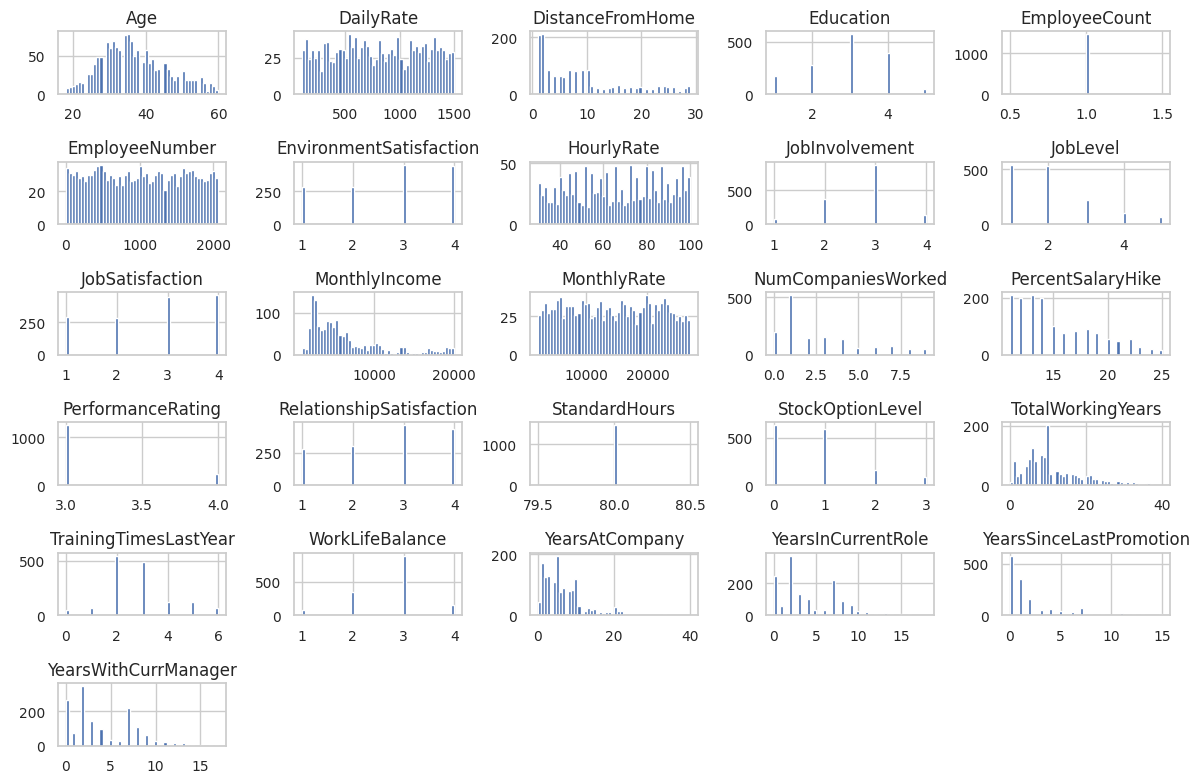

In [6]:
plt.rc('font', size=12)
plt.rc('axes', labelsize=12, titlesize=12)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

data.hist(bins=50, figsize=(12, 8))

plt.tight_layout()

plt.show()

Guardiamo quali sono i valori presenti per `Over18` e la loro frequenza.
Notiamo che anche questa feature non porta informazione utile perchè è sempre uguale a `Y`.

In [7]:
data["Over18"].value_counts()

,count
Over18,
Y,1470


Guardiamo anche la distribuzione per la variabile `Attrition`.

Notiamo che è sbilanciato, circa l'84% di "No" e circa il 16% di "Sì".

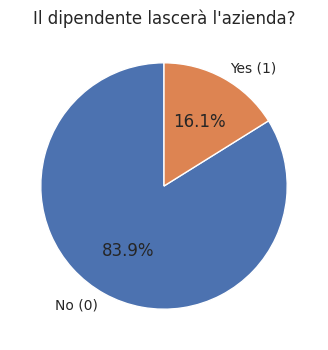

In [8]:
plt.figure(figsize=(4, 4))
counts = data['Attrition'].value_counts()
plt.pie(counts, labels=['No (0)', 'Yes (1)'], autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452'], startangle=90)

plt.title('Il dipendente lascerà l\'azienda?')
plt.show()

<a name="4"></a>
## 4. Pulizia delle feature
Anziché utilizzare tutte le features disponibili, droppiamo quelle che non forniscono informazioni utili.

Droppiamo le colonne `EmployeeCount`, `Over18`, `StandardHours` e `EmployeeNumber` perché contengono un unico valore costante per tutte le righe e quindi non portano informazione utile al modello. Rimuoviamo anche `EmployeeNumber`, un identificativo univoco del dipendente: se lasciato come feature, rischia di introdurre rumore o un pattern artificioso (data leakage) legato all'ID piuttosto che a caratteristiche reali.  

Eliminiamo i tassi di retribuzione secondari `DailyRate`, `HourlyRate` e `MonthlyRate`: queste variabili duplicano l'informazione sulla situazione economica del dipendente, che è già espressa in modo più accurato e stabile dalla feature principale `MonthlyIncome`.

In [9]:
cols_to_drop = [
    'EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber',
    'DailyRate', 'HourlyRate', 'MonthlyRate'
]
data.drop(columns=cols_to_drop, inplace=True)
data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,3,4,1,6,3,3,2,2,2,2


Trasformiamo la variabile target da testo (Yes/No) a numero (1/0)

In [10]:
data["Attrition"] = data["Attrition"].map({"Yes": 1, "No": 0})
data["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


<a name="5"></a>
## 5. Costruiamo Training e Test set

Dividiamo il dataset in training set (80%) e test set (20%) con `random_state=42` per garantire la riproducibilità dei risultati.

Utilizziamo il parametro `stratify` sulla variabile target perché il dataset è sbilanciato (~84% No, ~16% Yes): questo garantisce che la proporzione tra le due classi sia mantenuta sia nel training set che nel test set, rendendo il confronto tra i modelli più affidabile.

In [11]:
X = data.drop(columns=["Attrition"])
y = data["Attrition"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {len(X_train)}")
print(f"y_train: {len(y_train)}")
print(f"X_test: {len(X_test)}")
print(f"y_test: {len(y_test)}")

X_train: 1176
y_train: 1176
X_test: 294
y_test: 294


<a name="6"></a>
## 6. Exploratory Data Analysis (EDA)



Ricostruiamo un DataFrame temporaneo con training set + target, comodo per fare grafici

In [12]:
train_df = X_train.copy()
train_df["Attrition"] = y_train

Confrontiamo l'età dei dipendenti (`Age`) che restano e quelli che se ne vanno

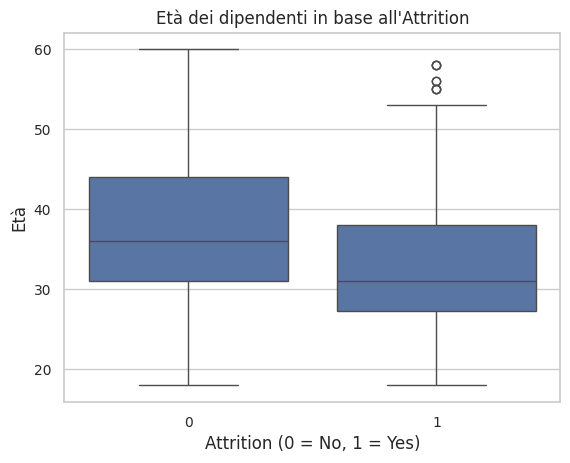

In [13]:
sns.boxplot(data=train_df, x="Attrition", y="Age")
plt.title("Età dei dipendenti in base all'Attrition")
plt.xlabel("Attrition (0 = No, 1 = Yes)")
plt.ylabel("Età")
plt.show()

Confrontiamo il reddito mensile(`MonthlyIncome`): spesso chi guadagna meno tende a lasciare di più

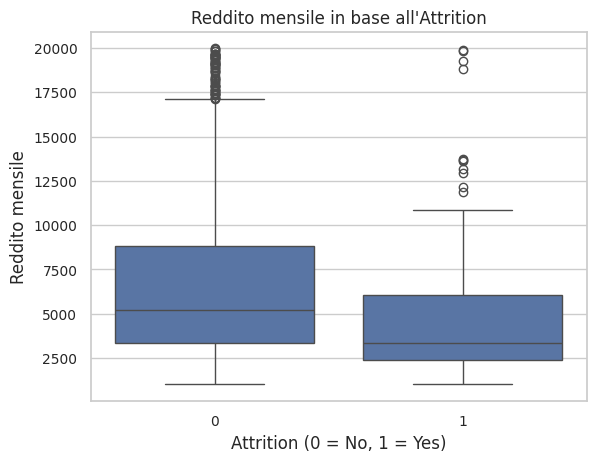

In [14]:
sns.boxplot(data=train_df, x="Attrition", y="MonthlyIncome")
plt.title("Reddito mensile in base all'Attrition")
plt.xlabel("Attrition (0 = No, 1 = Yes)")
plt.ylabel("Reddito mensile")
plt.show()

Vediamo se lo straordinario (`OverTime`) è collegato all' `Attrition`: calcoliamo la percentuale di Attrition=Yes per ciascun gruppo (Yes/No straordinario)

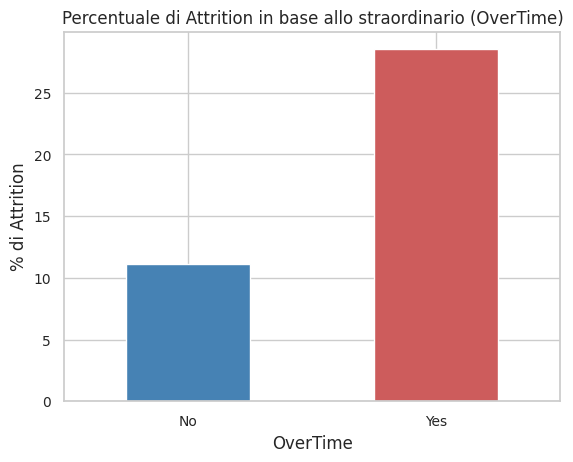

In [15]:
tasso_attrition = train_df.groupby("OverTime")["Attrition"].mean() * 100
tasso_attrition.plot(kind="bar", color=["steelblue", "indianred"])
plt.title("Percentuale di Attrition in base allo straordinario (OverTime)")
plt.ylabel("% di Attrition")
plt.xticks(rotation=0)
plt.show()

Heatmap di correlazione tra le variabili numeriche: ci aiuta a capire quali variabili sono più legate tra loro e con l'Attrition

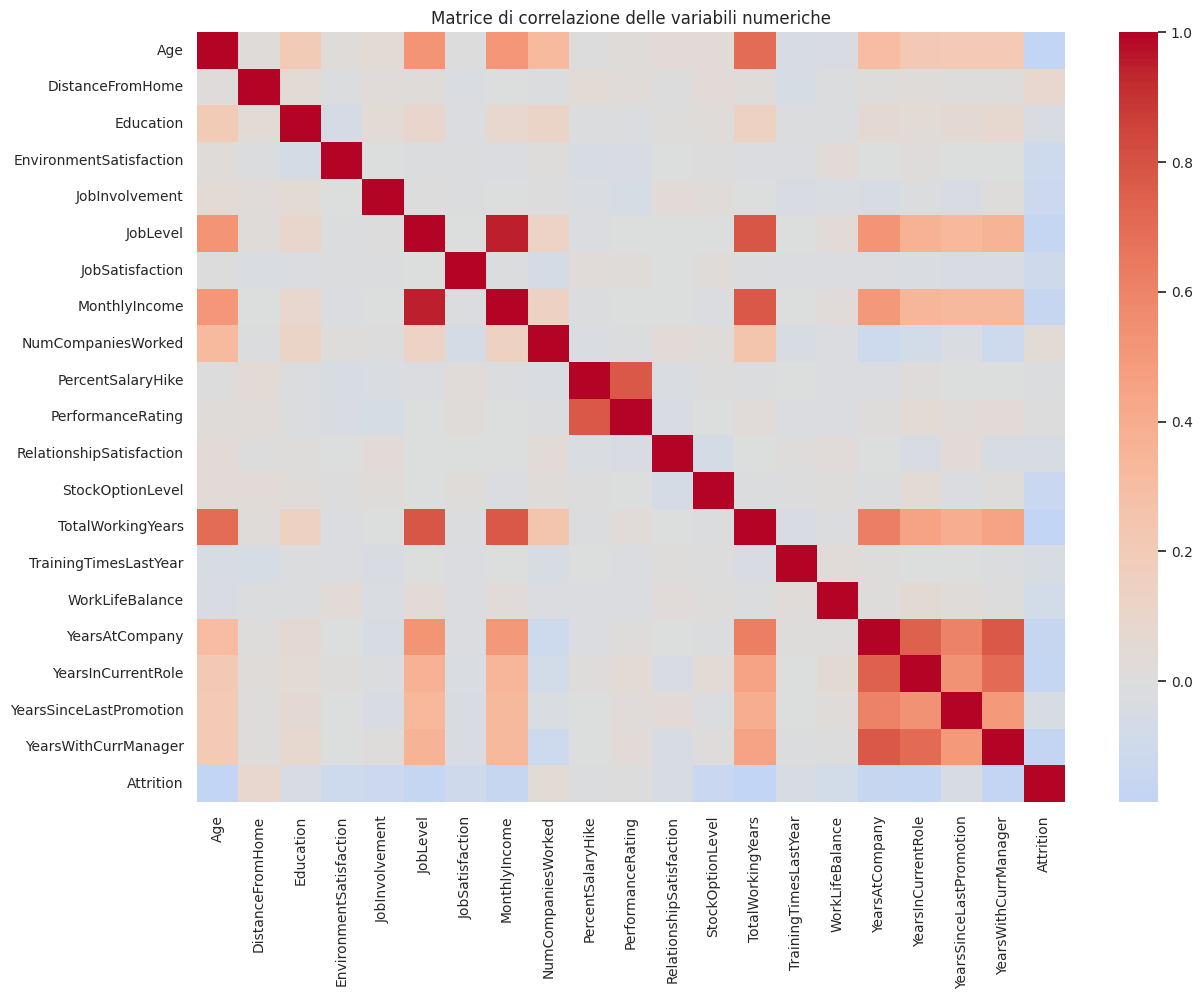

In [16]:
colonne_numeriche = train_df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(colonne_numeriche.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Matrice di correlazione delle variabili numeriche")
plt.show()

Correlazione:  
Per identificare le variabili numeriche più correlate con la variabile target `Attrition`, calcoliamo la correlazione di Pearson tra tutte le colonne numeriche e `Attrition`, ordinando i risultati in modo decrescente.

Le correlazioni positive indicano che all'aumentare della variabile aumenta la probabilità di Attrition: la più alta è `DistanceFromHome` (0.087), suggerendo che i dipendenti che abitano lontano dal luogo di lavoro tendono ad abbandonare l'azienda più frequentemente.

Le correlazioni negative indicano invece una relazione inversa: i valori più significativi sono `TotalWorkingYears` (-0.186), `Age` (-0.185) e `YearsWithCurrManager` (-0.169): i dipendenti più esperti, più anziani e con relazioni lavorative consolidate tendono a rimanere in azienda.

Notiamo anche che tutte le correlazioni risultano deboli (|r| < 0.20), significa che **nessuna singola variabile è sufficiente da sola a predire l'Attrition**: questo giustifica l'utilizzo di modelli non lineari come Random Forest, in grado di catturare interazioni complesse tra le variabili.

In [17]:
corr_matrix = colonne_numeriche.corr()
corr_matrix["Attrition"].sort_values(ascending=False)

,Attrition
Attrition,1.000000
DistanceFromHome,0.086744
NumCompaniesWorked,0.048648
PerformanceRating,0.007047
PercentSalaryHike,-0.009148
Education,-0.029742
TrainingTimesLastYear,-0.039445
YearsSinceLastPromotion,-0.042942
RelationshipSatisfaction,-0.043369
WorkLifeBalance,-0.080319


**Osservazioni principali dall'EDA:**
- Le classi sono sbilanciate (84% No / 16% Yes)  
- I dipendenti che lasciano l'azienda tendono ad essere leggermente più giovani e con reddito mensile più basso.
- Lo straordinario (`OverTime = Yes`) sembra associato a un tasso di Attrition più alto  
- Nessuna variabile numerica ha una correlazione fortissima da sola con Attrition: probabilmente dobbiamo usare la combinazione di più fattori

<a name="7"></a>
## 7. Preprocessing
Individuiamo quali colonne sono categoriche e quali numeriche

In [18]:
colonne_categoriche = X_train.select_dtypes(include="object").columns.tolist()
colonne_numeriche = X_train.select_dtypes(exclude="object").columns.tolist()

print("Colonne categoriche:", colonne_categoriche)
print("\nColonne numeriche:", colonne_numeriche)

Colonne categoriche: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Colonne numeriche: ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


One-Hot Encoding: trasformiamo le variabili categoriche (es. Department, JobRole...) in colonne numeriche 0/1, perché gli algoritmi di ML lavorano solo con numeri.

In [19]:
X_train_enc = pd.get_dummies(X_train, columns=colonne_categoriche, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=colonne_categoriche, drop_first=True)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print("Numero di feature dopo il One-Hot Encoding:", X_train_enc.shape[1])

Numero di feature dopo il One-Hot Encoding: 41


Standardizziamo le variabili numeriche (media 0, deviazione standard 1).  
È importante soprattutto per modelli come la Regressione Logistica, che sono sensibili alla scala delle variabili (es. MonthlyIncome ha valori molto più grandi di JobSatisfaction).

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

print("Preprocessing completato. Shape training set:", X_train_scaled.shape)

Preprocessing completato. Shape training set: (1176, 41)


<a name="8"></a>
## 8. Classificazione - predire Attrition (Yes/No)  
Proviamo due modelli diversi e li confrontiamo:
- **Regressione Logistica**: modello semplice e interpretabile, buon punto di partenza.
- **Random Forest**: modello più complesso, basato su tanti alberi decisionali, spesso più accurato.

Per entrambi usiamo il parametro `class_weight="balanced"`: dato che le classi sono sbilanciate (84% vs 16%), questo dice al modello di dare più "peso" agli errori commessi sulla classe minoritaria (Attrition = Yes)

In [21]:
# Modello 1: Regressione Logistica
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_proba_cv = cross_val_predict(
    log_reg, X_train_scaled, y_train,
    cv=cv, method="predict_proba"
)[:, 1]

print("Ricerca della soglia ottimale tramite cross-validation:")
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred_cv = (y_proba_cv >= threshold).astype(int)
    print(f"\nThreshold = {threshold}")
    print("Precision:", round(precision_score(y_train, y_pred_cv), 3))
    print("Recall   :", round(recall_score(y_train, y_pred_cv), 3))
    print("F1-score :", round(f1_score(y_train, y_pred_cv), 3))

Ricerca della soglia ottimale tramite cross-validation:

Threshold = 0.2
Precision: 0.245
Recall   : 0.889
F1-score : 0.384

Threshold = 0.3
Precision: 0.283
Recall   : 0.842
F1-score : 0.424

Threshold = 0.4
Precision: 0.323
Recall   : 0.795
F1-score : 0.459

Threshold = 0.5
Precision: 0.361
Recall   : 0.716
F1-score : 0.48

Threshold = 0.6
Precision: 0.44
Recall   : 0.658
F1-score : 0.527


Ho valutato diverse soglie decisionali (0,2–0,6) per la regressione logistica usando la
cross-validation (5-fold) sul training set, in modo da non "sbirciare" il test set durante
questa fase di scelta. Le previsioni di probabilità sono quelle out-of-fold, quindi ogni
osservazione è valutata da un modello che non l'ha vista in fase di training.

Come atteso, soglie più basse aumentano il recall a scapito della precisione: a soglia 0,2
il modello intercetta l'89% dei dipendenti che lasciano l'azienda, ma con una precisione
molto bassa (0,245), cioè genera molti falsi allarmi. Aumentando la soglia, la precisione
migliora progressivamente mentre il recall scende.

Tra i valori testati, la soglia 0,6 ottiene il punteggio F1 più alto (0,527), con un buon
equilibrio tra precision (0,44) e recall (0,658). Le soglie più basse offrono un recall
maggiore (es. 0,795 a soglia 0,4) ma a costo di una precisione nettamente inferiore (0,323).

Ho scelto la soglia **0,6** perché offre il miglior compromesso complessivo (F1 più alto),
pur mantenendo un recall accettabile (65,8%) per un caso d'uso come questo, dove mancare
troppi falsi allarmi (bassa precisione) rischia di far perdere credibilità al modello agli
occhi dell'HR.

In [22]:
threshold = 0.6

log_reg.fit(X_train_scaled, y_train)

y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_log = (y_proba_log >= threshold).astype(int)

In [23]:
# Modello 2: Random Forest
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)

y_proba_rf_cv = cross_val_predict(
    rf, X_train_scaled, y_train,
    cv=cv, method="predict_proba"
)[:, 1]

print("Ricerca della soglia ottimale per Random Forest tramite cross-validation:")
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred_cv = (y_proba_rf_cv >= threshold).astype(int)
    print(f"\nThreshold = {threshold}")
    print("Precision:", round(precision_score(y_train, y_pred_cv), 3))
    print("Recall   :", round(recall_score(y_train, y_pred_cv), 3))
    print("F1-score :", round(f1_score(y_train, y_pred_cv), 3))

Ricerca della soglia ottimale per Random Forest tramite cross-validation:

Threshold = 0.2
Precision: 0.451
Recall   : 0.647
F1-score : 0.531

Threshold = 0.3
Precision: 0.576
Recall   : 0.4
F1-score : 0.472

Threshold = 0.4
Precision: 0.764
Recall   : 0.289
F1-score : 0.42

Threshold = 0.5
Precision: 0.854
Recall   : 0.184
F1-score : 0.303

Threshold = 0.6
Precision: 0.9
Recall   : 0.095
F1-score : 0.171


I risultati mostrano un pattern molto diverso rispetto alla Regressione Logistica: il Random Forest è molto più "conservativo" nel restituire probabilità alte per la classe minoritaria (Attrition = Yes).

Il miglior punteggio F1 si ottiene alla soglia più bassa testata (0,2), con F1 = 0,531, precision = 0,451 e recall = 0,647.  

Scelgo quindi **soglia 0,2** per il Random Forest, che massimizza l'F1-score tra i valori testati e riporta il recall su un livello comparabile a quello della Regressione Logistica,  rendendo il confronto finale tra i due modelli più equo.

In [24]:
threshold_rf = 0.2

rf.fit(X_train_scaled, y_train)

y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = (y_proba_rf >= threshold_rf).astype(int)

Matrici di confusione: ci mostrano visivamente gli errori del modello (falsi positivi e falsi negativi) per entrambi i modelli

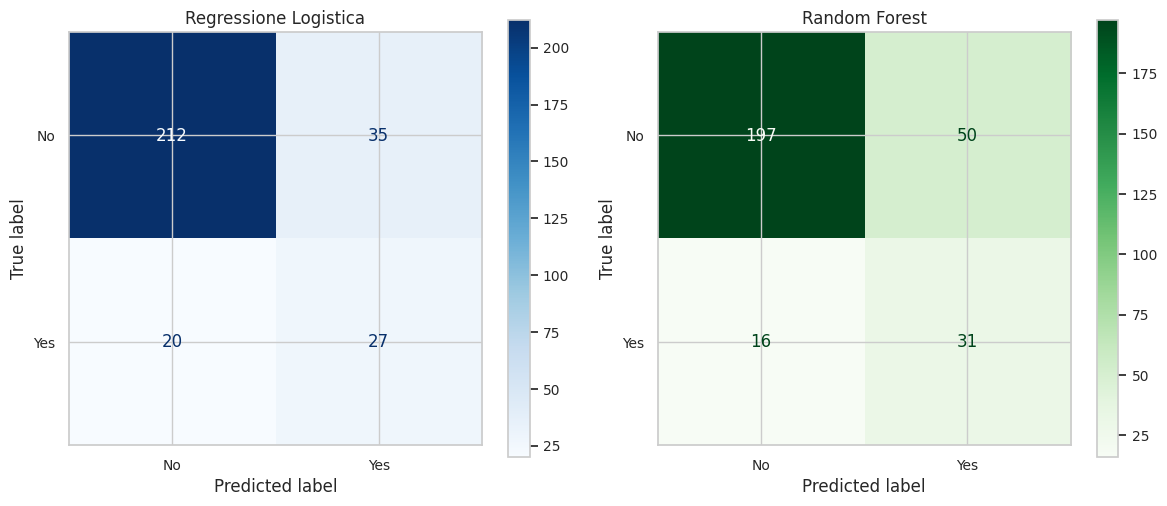

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=axes[0],
                                         display_labels=["No", "Yes"], cmap="Blues")
axes[0].set_title("Regressione Logistica")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1],
                                         display_labels=["No", "Yes"], cmap="Greens")
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

Guardiamo anche la curva ROC: mostra il compromesso tra veri positivi e falsi positivi al variare della soglia di decisione.  

Le curve ROC di entrambi i modelli si trovano al di sopra della linea del classificatore casuale, indicando una buona capacità di discriminare tra le classi. La regressione logistica dimostra prestazioni leggermente migliori, poiché la sua curva ROC si trova al di sopra della curva del Random Forest per la maggior parte del suo intervallo.  

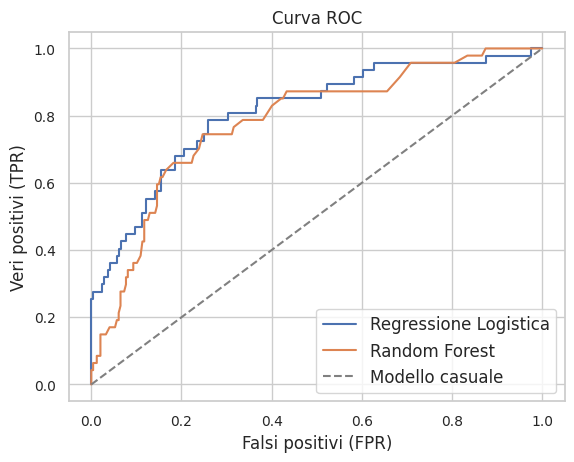

In [26]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.plot(fpr_log, tpr_log, label="Regressione Logistica")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modello casuale")
plt.xlabel("Falsi positivi (FPR)")
plt.ylabel("Veri positivi (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.show()

Funzione di supporto per calcolare e stampare le metriche principali di un modello.     
Usiamo più metriche perché le classi sono sbilanciate:  
 - **Precision**: quando il modello dice "Yes", quante volte ha ragione?
 - **Recall**: tra tutti i dipendenti che hanno davvero lasciato, quanti ne troviamo?
 - **F1-score**: media armonica tra precision e recall
 - **ROC-AUC**: capacità del modello di distinguere le due classi in generale

In [27]:
def valuta_modello(nome, y_true, y_pred, y_proba):
    print(f"--- {nome} ---")
    print("Accuratezza:", round(accuracy_score(y_true, y_pred), 3))
    print("Precision  :", round(precision_score(y_true, y_pred), 3))
    print("Recall     :", round(recall_score(y_true, y_pred), 3))
    print("F1-score   :", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC    :", round(roc_auc_score(y_true, y_proba), 3))
    print()

valuta_modello("Regressione Logistica", y_test, y_pred_log, y_proba_log)
valuta_modello("Random Forest", y_test, y_pred_rf, y_proba_rf)

--- Regressione Logistica ---
Accuratezza: 0.813
Precision  : 0.435
Recall     : 0.574
F1-score   : 0.495
ROC-AUC    : 0.811

--- Random Forest ---
Accuratezza: 0.776
Precision  : 0.383
Recall     : 0.66
F1-score   : 0.484
ROC-AUC    : 0.782



Il Random Forest ci permette anche di capire **quali variabili sono state più importanti per le sue previsioni**  

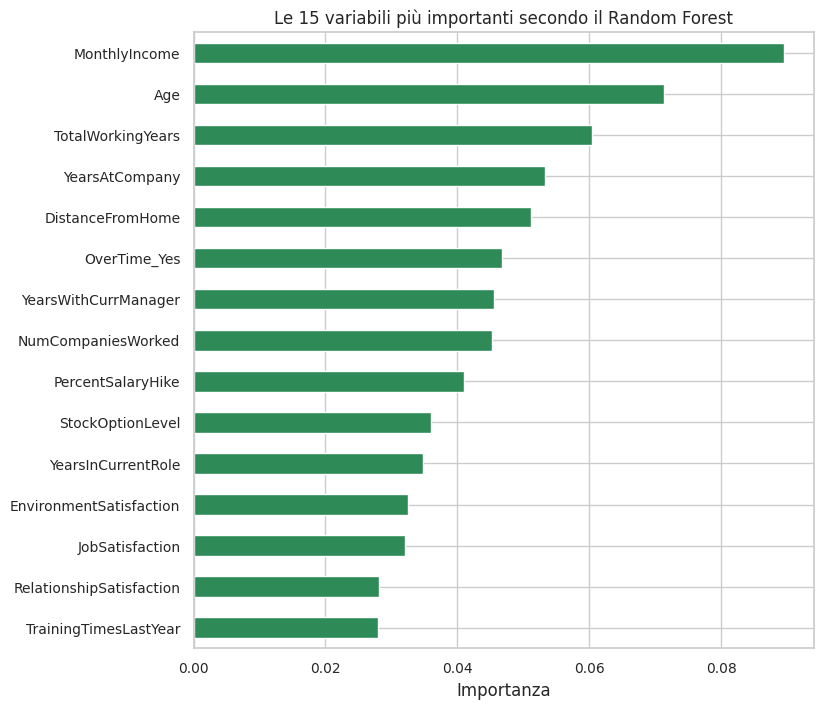

In [28]:
importanze = pd.Series(rf.feature_importances_, index=X_train_enc.columns)
importanze = importanze.sort_values(ascending=False).head(15)

importanze.sort_values().plot(kind="barh", figsize=(8, 8), color="seagreen")
plt.title("Le 15 variabili più importanti secondo il Random Forest")
plt.xlabel("Importanza")
plt.show()

<a name="9"></a>
## 9. Conclusioni e idee per il miglioramento

**Cosa abbiamo fatto:**
- Abbiamo esplorato il dataset IBM HR Analytics e individuato che il fenomeno dell'Attrition riguarda circa il 16% dei dipendenti (classi sbilanciate).
- Abbiamo eliminato le colonne non informative (costanti o puramente identificative).
- Abbiamo costruito training e test set in modo stratificato, per rispettare la proporzione originale delle classi.
- Abbiamo trasformato le variabili categoriche con il One-Hot Encoding e standardizzato le variabili numeriche.
- Abbiamo addestrato e confrontato due modelli di classificazione: Regressione Logistica e Random Forest, valutandoli con più metriche oltre alla semplice accuratezza.
- Abbiamo individuato le variabili più rilevanti per l'Attrition (ad esempio reddito mensile, età, ore di straordinario, anni in azienda).

**Limiti del modello attuale:**
- Il dataset è relativamente piccolo (circa 1470 dipendenti) e sbilanciato: la classe "Yes" (chi lascia l'azienda) ha pochi esempi, quindi il modello fatica di più a riconoscerla correttamente (recall più basso rispetto alla classe "No").
- Non abbiamo fatto un tuning approfondito degli iperparametri dei modelli.

**Possibili miglioramenti futuri:**
1. **Tuning degli iperparametri**: usare `GridSearchCV` o `RandomizedSearchCV` per ottimizzare parametri come il numero di alberi del Random Forest.
2. **Provare altri modelli**: ad esempio Gradient Boosting, XGBoost.
3. **Feature engineering**: creare nuove variabili derivate (es. rapporto tra anni nel ruolo attuale e anni totali di lavoro) che potrebbero catturare meglio il fenomeno.
4. **Validazione più robusta**: usare la cross-validation invece di un singolo train/test split, per avere stime più stabili delle performance.
